In [1]:
%cd ~/cdv
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import rho_plus as rp

import os
os.environ['CUDA_VISIBLE_DEVICES'] = ''

import jax
import jax.numpy as jnp

is_dark = False
theme, cs = rp.mpl_setup(is_dark)

/home/nmiklaucic/miniconda3/envs/avid/lib/python3.12/site-packages/IPython/core/magics/osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})
/home/nmiklaucic/miniconda3/envs/avid/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/home/nmiklaucic/cdv


In [20]:
df = pd.read_feather(f'data/enb-201_test.feather')
df['rotation'] = df['rotation'].fillna('N/A').astype('category')
df['residual'] = df.eval('abs(prediction - target)')
df

,dataset_id,target,prediction,rotation,residual
0,1741045015,-6.616924,-6.628114,N/A,0.011190
1,1757710000,-7.527099,-7.522349,N/A,0.004749
2,1695979023,-4.768504,-4.778116,N/A,0.009612
3,1721013021,-6.456432,-6.458467,N/A,0.002034
4,-1660321872,-6.519560,-6.463128,N/A,0.056433
...,...,...,...,...,...
400321,-1861591888,-2.135977,-2.156050,1.0,0.020073
400322,1766001,-6.591775,-6.625021,1.0,0.033246
400323,-1816412886,-5.527549,-5.536975,1.0,0.009426
400324,1567809008,-2.621080,-2.619542,1.0,0.001539


In [32]:
df.groupby(['dataset_id'], observed=True).mean(numeric_only=True).eval('1000 * abs(prediction - target)').mean()

30.19852507895835

In [24]:
df.groupby(['rotation'], observed=True).mean() * 1000

,dataset_id,target,prediction,residual
rotation,,,,
0.0,-3.011770e+11,-6256.061611,-6260.096295,30.453251
1.0,-3.011770e+11,-6256.061611,-6260.082862,30.447130
N/A,-3.011770e+11,-6256.061611,-6260.089807,30.449709


In [2]:
dfs = []
models = ['enb-197', 'enb-198', 'enb-199', 'enb-201']
for model in models:
    for split in ('train', 'valid', 'test'):
        dfs.append(pd.read_feather(f'data/{model}_{split}.feather'))
        dfs[-1]['split'] = split
        dfs[-1]['model'] = model

df = pd.concat(dfs).reset_index()
df['split'] = pd.Categorical(df['split'], categories=['train', 'valid', 'test'], ordered=True)
df['model'] = pd.Categorical(df['model'])

df.shape

(6215166, 6)

In [3]:
df.query('model == "enb-197"')['split'].value_counts()

split
train    1314492
test      133442
valid     132554
Name: count, dtype: int64

In [4]:
pivoted = df.pivot_table(index=['index', 'split'], columns='model', values=['prediction', 'target'], observed=False)
pivoted.columns = models + ['target'] + ['target2'] * (len(models) - 1)
pivoted.drop(columns=['target2'], inplace=True)
pivoted

enb-197   enb-198   enb-199   enb-201    target
index   split                                                  
0       train -7.450242 -7.446835 -7.451971 -7.450560 -7.449115
        valid -4.543889 -4.527889 -4.576456 -4.557632 -4.560117
        test  -6.615935 -6.616247 -6.609588 -6.628151 -6.616924
1       train -8.074464 -8.072561 -8.073508 -8.075271 -8.068948
        valid -3.482732 -3.422691 -3.483650 -3.463713 -3.444715
...                 ...       ...       ...       ...       ...
1314487 train -4.200040 -4.237227 -4.214700 -4.185102 -4.113819
1314488 train -7.813198 -7.824353 -7.822027 -7.824944 -7.813792
1314489 train -9.255919 -9.282350 -9.261489 -9.305616 -9.289242
1314490 train -6.490796 -6.450808 -6.500042 -6.492524 -6.486058
1314491 train -9.395794 -9.441685 -9.472312 -9.377337 -9.356917

[1580488 rows x 5 columns]

In [5]:
pivoted['mean'] = pivoted[models].mean(axis=1)

In [6]:
((pivoted - pivoted[['target']].values).abs().mean(axis=0) * 1000).round(2).to_frame()

,0
enb-197,15.35
enb-198,15.67
enb-199,15.50
enb-201,16.45
target,0.00
mean,12.91


In [7]:
res_df = ((pivoted - pivoted[['target']].values).abs().groupby('split').mean() * 1000).round(2)

res_df.loc['all', :] = ((pivoted - pivoted[['target']].values).abs().mean(axis=0) * 1000).round(2).T
res_df

/tmp/ipykernel_1087342/2646053960.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  res_df = ((pivoted - pivoted[['target']].values).abs().groupby('split').mean() * 1000).round(2)


,enb-197,enb-198,enb-199,enb-201,target,mean
split,,,,,,
train,12.78,13.13,12.98,14.61,0.0,10.71
valid,28.58,29.13,28.72,31.88,0.0,24.50
test,27.53,27.38,27.23,30.45,0.0,23.09
all,15.35,15.67,15.50,16.45,0.0,12.91


In [10]:
from facet.data.dataset_generation import parse_data_id_mptrj


parse_data_id_mptrj(df['dataset_id'][4])

'mp-556783-1-3'

In [11]:
df['err'] = df.eval('target - prediction')
df['abs_err'] = np.abs(df['err'])

worst = df.sort_values('abs_err', ascending=False).head(30)
worst.head()

,index,dataset_id,target,prediction,split,model,err,abs_err
1152873,1152873,1936295000,-1.809825,-7.023074,train,enb-197,5.213249,5.213249
1871285,290797,1808843000,-0.902183,-6.045436,train,enb-198,5.143254,5.143254
4313849,1152873,1936295000,-1.809825,-6.702785,train,enb-199,4.892959,4.892959
2744061,1163573,-1365746880,-4.238377,-9.082997,train,enb-198,4.844621,4.844621
4324549,1163573,-1365746880,-4.238377,-9.077722,train,enb-199,4.839345,4.839345


In [12]:
df.groupby(['model', 'dataset_id']).mean(numeric_only=True)

/tmp/ipykernel_1087342/1485651665.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['model', 'dataset_id']).mean(numeric_only=True)


index    target  prediction       err   abs_err
model   dataset_id                                                          
enb-197 -1883890888  126881.000000 -9.456453   -9.495733  0.039280  0.039280
        -1883890886   43449.333333 -9.361979   -9.443167  0.081188  0.081188
        -1883890885   94776.000000 -9.074412   -9.085427  0.011014  0.049210
        -1883890884   98962.000000 -9.439379   -9.485208  0.045828  0.045828
        -1883890880   61798.000000 -9.433409   -9.486569  0.053161  0.053161
...                            ...       ...         ...       ...       ...
enb-201  1999566005            NaN       NaN         NaN       NaN       NaN
         1999576000            NaN       NaN         NaN       NaN       NaN
         1999576001    2025.000000 -8.637803   -8.576093 -0.061710  0.061710
         1999576002    1257.000000 -8.637930   -8.577929 -0.060000  0.060000
         1999576003            NaN       NaN         NaN       NaN       NaN

[5069156 rows x 5 columns]

In [13]:
from sklearn.metrics import r2_score

r2_score(df['prediction'], df['target'])

0.999427264216682

In [14]:
df.groupby('split').mean(numeric_only=True)['abs_err'].round(5) * 1000

/tmp/ipykernel_1087342/3418772384.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('split').mean(numeric_only=True)['abs_err'].round(5) * 1000


split
train    13.37
valid    29.58
test     27.57
Name: abs_err, dtype: float64

In [15]:
df['abs_err'].mean().round(5) * 1000

15.73

In [16]:
worst_ds_ids = [parse_data_id_mptrj(x) for x in worst['dataset_id']]
worst_mp_ids = [s.rsplit('-', maxsplit=2)[0] for s in worst_ds_ids if s.startswith('mp')]
worst_mp_ids

['mp-936295',
 'mp-808843',
 'mp-936295',
 'mp-936295',
 'mp-808843',
 'mp-555394',
 'mp-555394',
 'mp-555394',
 'mp-555394',
 'mp-936295',
 'mp-614724',
 'mp-614724',
 'mp-614724',
 'mp-614724',
 'mp-808843',
 'mp-808843',
 'mp-694932']

In [17]:
from mp_api.client import MPRester

with MPRester() as mpr:
    docs = mpr.materials.summary.search(material_ids=worst_mp_ids)

Retrieving SummaryDoc documents:   0%|          | 0/10 [00:00<?, ?it/s]

In [18]:
[doc.composition.to_pretty_string() for doc in docs]

['V2O3F3',
 'Ta22O4',
 'Cs6Cr2F14',
 'V2O3F3',
 'V2O3F3',
 'Si16O32',
 'Si16O32',
 'Ta22O4',
 'Cs6Cr2F14',
 'Na2Co6O12']

<Axes: xlabel='err', ylabel='Count'>

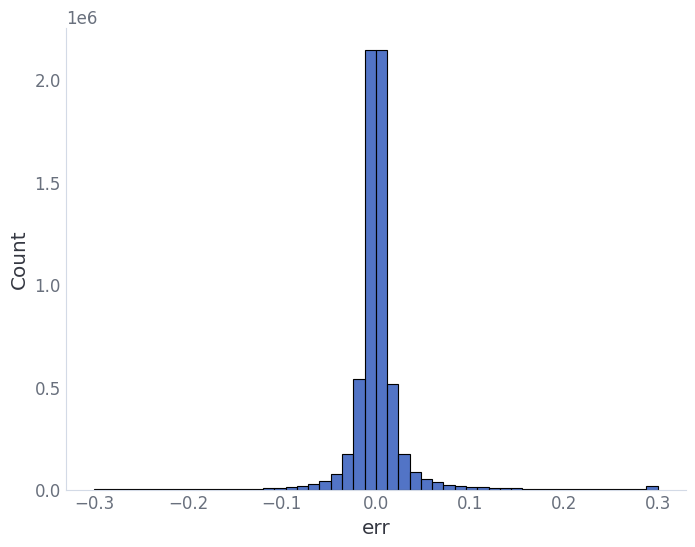

In [19]:
sns.histplot(df['err'].clip(-0.3, 0.3), bins=50)

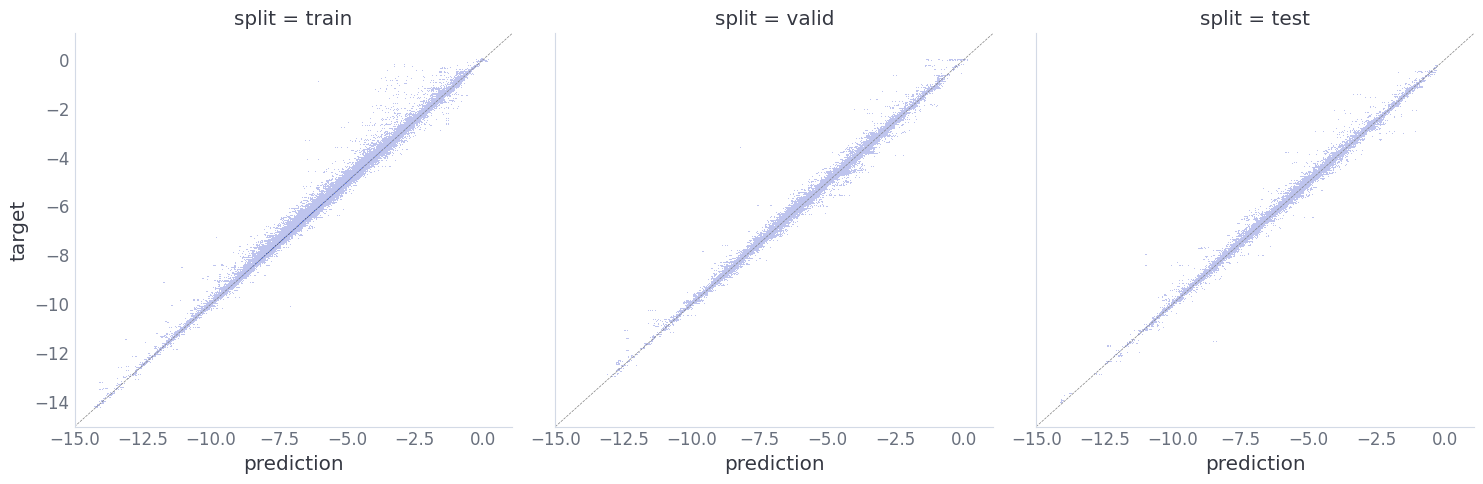

In [20]:
g = sns.displot(df, x='prediction', y='target', col='split')

xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()

newmin, newmax = min(xmin, ymin), max(xmax, ymax)

plt.xlim(newmin, newmax)
plt.ylim(newmin, newmax)

for ax in g.axes.flatten():
    ax.axline((0, 0), slope=1, ls='--', lw=0.5, color='grey')